<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Soil-Kriging-Analysis/blob/main/kriging_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Spasial Kandungan Zinc Tanah Menggunakan Ordinary Kriging

# 1. IMPORT LIBRARY

In [2]:
# =============================================================================
# 0. INSTALL LIBRARY
# =============================================================================

!pip install pykrige
!pip install scikit-gstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 710.3/710.3 kB 11.2 MB/s eta 0:00:00


In [3]:
# =============================================================================
# 1. IMPORT LIBRARY
# =============================================================================


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy.interpolate import griddata


from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


from pykrige.ok import OrdinaryKriging
from pykrige.kriging_tools import write_asc_grid


import warnings
warnings.filterwarnings("ignore")


# Style visualisasi

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. IMPORT DATA SPASIAL ZINC

In [5]:
# =============================================================================
# 2. IMPORT DATA SPASIAL ZINC
# =============================================================================

print("="*80)
print("TAHAP 1: IMPORT DATA SPASIAL ZINC")
print("="*80)


# Upload file secara manual

from google.colab import files


uploaded = files.upload()


# mengambil nama file yang diupload

filename = list(uploaded.keys())[0]


print("\nFile yang digunakan:")
print(filename)



# membaca data excel

data = pd.read_excel(filename)



print("\nUkuran data:")
print(data.shape)



print("\nInformasi data:")
data.info()



print("\n5 data pertama:")
display(data.head())

TAHAP 1: IMPORT DATA SPASIAL ZINC


Saving soil.xlsx to soil.xlsx

File yang digunakan:
soil.xlsx

Ukuran data:
(155, 4)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       155 non-null    int64
 1   y       155 non-null    int64
 2   lead    155 non-null    int64
 3   zinc    155 non-null    int64
dtypes: int64(4)
memory usage: 5.0 KB

5 data pertama:


,x,y,lead,zinc
0,181072,333611,299,1022
1,181025,333558,277,1141
2,181165,333537,199,640
3,181298,333484,116,257
4,181307,333330,117,269


# 3. PEMILIHAN VARIABEL ANALISIS

In [6]:
# =============================================================================
# 3. PEMILIHAN VARIABEL ANALISIS
# =============================================================================


x = data["x"].values

y = data["y"].values

zinc = data["zinc"].values



print("Jumlah titik observasi :", len(zinc))


print("\nStatistik Zinc")

print(
    pd.DataFrame(
        zinc,
        columns=["Zinc"]
    ).describe()
)

Jumlah titik observasi : 155

Statistik Zinc
              Zinc
count   155.000000
mean    469.716129
std     367.073788
min     113.000000
25%     198.000000
50%     326.000000
75%     674.500000
max    1839.000000


# 4. EXPLORATORY DATA ANALYSIS

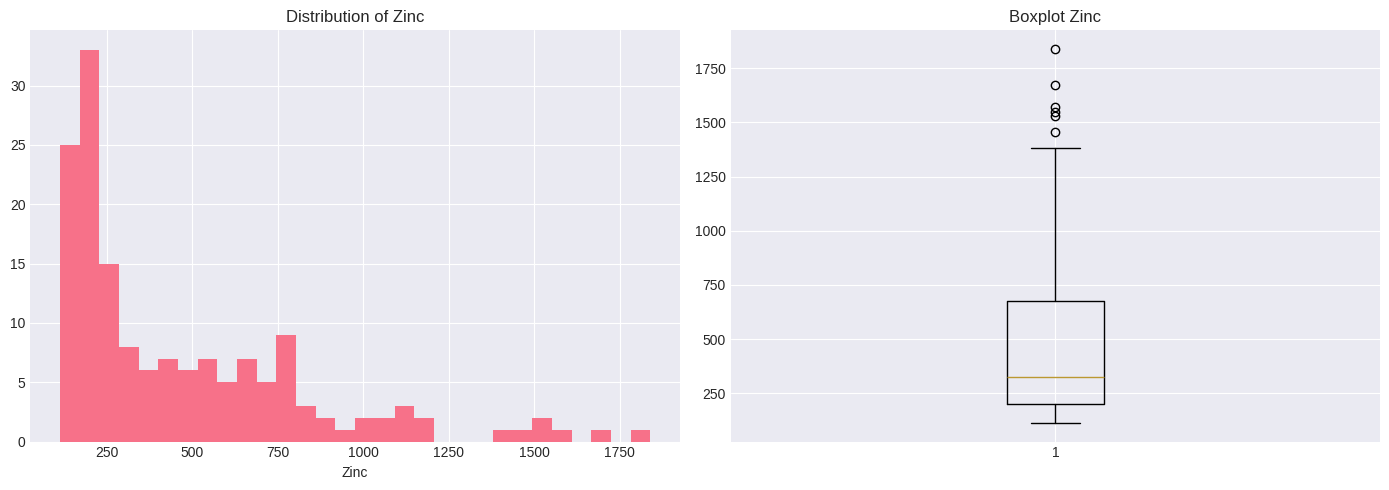

In [7]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS
# =============================================================================


fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,5)
)


# Histogram

ax[0].hist(
    zinc,
    bins=30
)

ax[0].set_title(
    "Distribution of Zinc"
)

ax[0].set_xlabel(
    "Zinc"
)



# Boxplot

ax[1].boxplot(
    zinc
)

ax[1].set_title(
    "Boxplot Zinc"
)



plt.tight_layout()

plt.show()

Berdasarkan histogram dan boxplot:

distribusi Zinc menunjukkan kecenderungan menceng ke kanan,
terdapat beberapa nilai ekstrem,
sehingga diperlukan transformasi agar varians lebih stabil sebelum analisis geostatistik.



# 5. TRANSFORMASI LOG ZINC

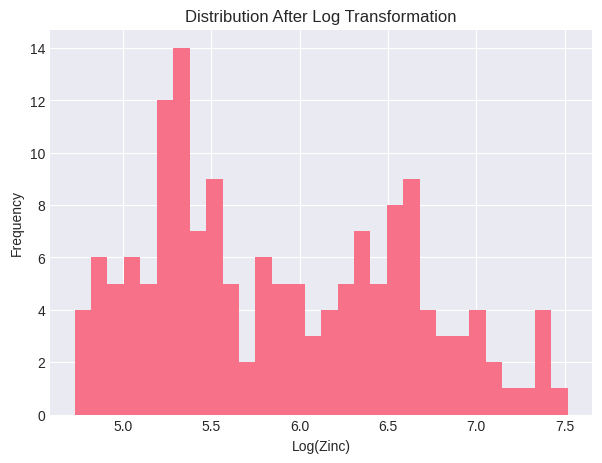

In [8]:
# =============================================================================
# 5. TRANSFORMASI LOGARITMA
# =============================================================================


zinc_log = np.log(zinc)



plt.figure(figsize=(7,5))


plt.hist(
    zinc_log,
    bins=30
)


plt.xlabel(
    "Log(Zinc)"
)


plt.ylabel(
    "Frequency"
)


plt.title(
    "Distribution After Log Transformation"
)


plt.show()

Transformasi logaritma dilakukan untuk:

mengurangi pengaruh pencilan,
memperbaiki distribusi data,
meningkatkan kestabilan varians.

Selanjutnya analisis variogram dilakukan menggunakan Log(Zinc).

# 6. VISUALISASI DATA SPASIAL

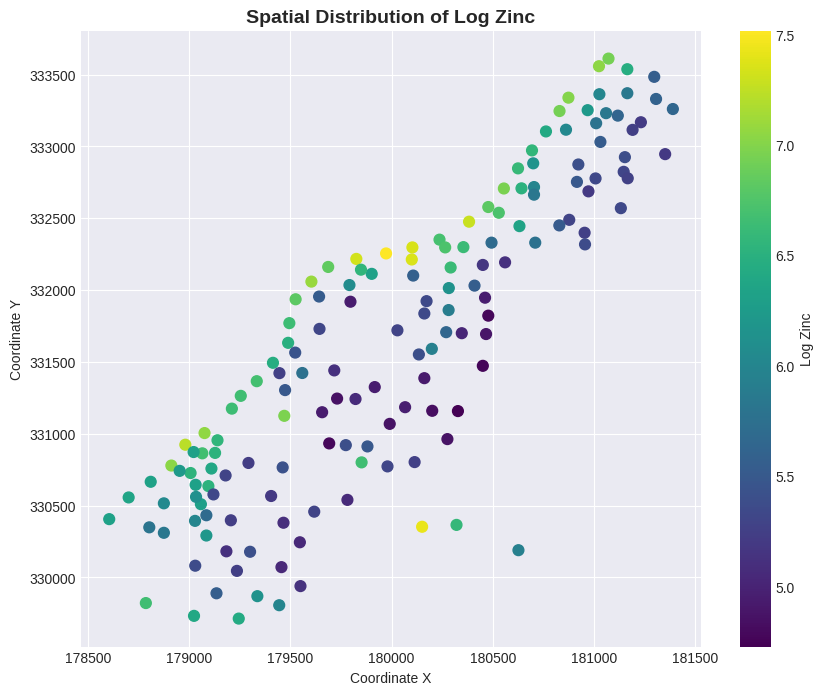

In [9]:
# =============================================================================
# 6. PETA DISTRIBUSI ZINC
# =============================================================================


plt.figure(figsize=(10,8))


scatter = plt.scatter(
    x,
    y,
    c=zinc_log,
    cmap="viridis",
    s=60
)


plt.colorbar(
    scatter,
    label="Log Zinc"
)


plt.xlabel(
    "Coordinate X"
)

plt.ylabel(
    "Coordinate Y"
)


plt.title(
    "Spatial Distribution of Log Zinc",
    fontsize=14,
    fontweight="bold"
)


plt.show()

Berdasarkan visualisasi distribusi spasial Log(Zinc), terdapat variasi nilai Zinc antar lokasi pengamatan dan indikasi adanya pola ketergantungan spasial. Lokasi yang berdekatan cenderung memiliki nilai yang relatif serupa, sehingga analisis variogram dan metode Ordinary Kriging dapat diterapkan untuk memodelkan serta memprediksi distribusi Zinc pada lokasi yang tidak diamati.

# 7. ANALISIS VARIOGRAM EMPIRIS

Variogram digunakan untuk mengukur hubungan ketergantungan spasial antar lokasi pengamatan.

Konsepnya:

Jika dua lokasi berdekatan memiliki nilai Zinc yang mirip → semivariance kecil.
Jika jarak semakin jauh dan nilai semakin berbeda → semivariance meningkat.

In [11]:
# =============================================================================
# 7. ANALISIS VARIOGRAM EMPIRIS
# =============================================================================

print("\n" + "="*80)
print("ANALISIS VARIOGRAM")
print("="*80)


def compute_variogram(x, y, z, max_dist=None, n_lags=20):
    """
    Menghitung experimental variogram
    """

    # Membuat koordinat
    coords = np.column_stack([x, y])


    # Menghitung jarak antar titik
    dist_matrix = squareform(
        pdist(coords)
    )


    # Perbedaan nilai
    z_matrix = z.reshape(-1,1)

    z_diff = z_matrix - z_matrix.T


    # Semivariance
    gamma_matrix = 0.5 * (z_diff**2)



    # Mengambil pasangan unik
    upper = np.triu_indices_from(
        dist_matrix,
        k=1
    )


    distances = dist_matrix[upper]

    gammas = gamma_matrix[upper]



    # batas jarak maksimum

    if max_dist is None:

        max_dist = distances.max()



    # Membagi menjadi lag

    lag_width = max_dist/n_lags



    lag_distance=[]

    lag_variogram=[]

    pair_counts=[]



    for i in range(n_lags):


        lower=i*lag_width

        upper_limit=(i+1)*lag_width



        mask=(distances>=lower)&(distances<upper_limit)



        if mask.sum()>0:


            lag_distance.append(
                distances[mask].mean()
            )


            lag_variogram.append(
                gammas[mask].mean()
            )


            pair_counts.append(
                mask.sum()
            )


    return (
        np.array(lag_distance),
        np.array(lag_variogram),
        np.array(pair_counts)
    )



# Menentukan jarak maksimum

max_dist = (
    np.sqrt(
        (x.max()-x.min())**2 +
        (y.max()-y.min())**2
    )
    *0.6
)



# Hitung variogram

distances, variogram, pair_counts = compute_variogram(
    x,
    y,
    zinc_log,
    max_dist=max_dist,
    n_lags=20
)



print("Variogram empiris berhasil dihitung")

print(
    f"Jumlah lag : {len(distances)}"
)

print(
    f"Jarak maksimum : {max_dist:.2f}"
)


ANALISIS VARIOGRAM
Variogram empiris berhasil dihitung
Jumlah lag : 20
Jarak maksimum : 2873.92


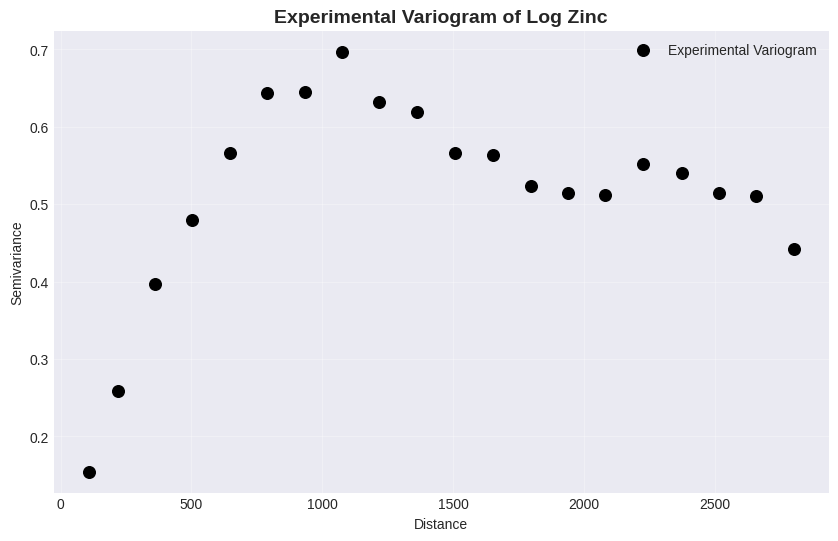

In [12]:
# =============================================================================
# 8. VISUALISASI EXPERIMENTAL VARIOGRAM
# =============================================================================


plt.figure(figsize=(10,6))


plt.scatter(
    distances,
    variogram,
    s=70,
    color="black",
    label="Experimental Variogram"
)



plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Semivariance"
)


plt.title(
    "Experimental Variogram of Log Zinc",
    fontsize=14,
    fontweight="bold"
)



plt.grid(
    alpha=0.3
)


plt.legend()


plt.show()

Berdasarkan experimental variogram Log(Zinc), terlihat adanya struktur ketergantungan spasial pada data. Nilai semivariance meningkat seiring bertambahnya jarak antar lokasi pengamatan dan kemudian mencapai kondisi relatif stabil. Hal ini menunjukkan bahwa kandungan Zinc memiliki autokorelasi spasial hingga jarak tertentu. Oleh karena itu, pemodelan variogram teoritis menggunakan beberapa model seperti exponential, spherical, dan gaussian dapat dilakukan untuk menentukan model terbaik sebelum proses Ordinary Kriging.

# 9. FITTING MODEL VARIOGRAM TEORITIS

Tahap ini bertujuan mencari model teoritis yang paling sesuai dengan experimental variogram.

Model yang diuji:

Exponential
Spherical
Gaussian

Parameter yang dicari:

Nugget → variasi pada jarak sangat kecil / error pengukuran
Sill → batas maksimum semivariance
Range → jarak maksimum adanya pengaruh spasial

Model terbaik nanti dipilih berdasarkan nilai SSE (Sum of Squared Error) terkecil.

In [15]:
# =============================================================================
# 9. FITTING MODEL VARIOGRAM TEORITIS
# =============================================================================

print("\n" + "="*80)
print("FITTING MODEL VARIOGRAM TEORITIS")
print("="*80)



# ============================================================
# Fungsi Model Variogram
# ============================================================


def variogram_model_exponential(h, nugget, sill, range_param):

    return (
        nugget +
        sill *
        (1 - np.exp(-h / range_param))
    )



def variogram_model_spherical(h, nugget, sill, range_param):

    gamma = np.zeros_like(h)


    mask = h <= range_param


    gamma[mask] = (
        nugget +
        sill *
        (
            1.5*(h[mask]/range_param)
            -
            0.5*(h[mask]/range_param)**3
        )
    )


    gamma[~mask] = nugget + sill


    return gamma



def variogram_model_gaussian(h, nugget, sill, range_param):

    return (
        nugget +
        sill *
        (
            1 -
            np.exp(-(h/range_param)**2)
        )
    )


FITTING MODEL VARIOGRAM TEORITIS


In [17]:
# ============================================================
# Fungsi Optimasi Fitting
# ============================================================


def fit_variogram(
    distances,
    variogram,
    model_type
):


    # initial parameter

    nugget_init = variogram[0]

    sill_init = max(variogram)-nugget_init

    range_init = distances[
        np.argmax(variogram)
    ]



    def objective(params):

        nugget, sill, range_param = params


        if model_type=="exponential":

            pred = variogram_model_exponential(
                distances,
                nugget,
                sill,
                range_param
            )


        elif model_type=="spherical":

            pred = variogram_model_spherical(
                distances,
                nugget,
                sill,
                range_param
            )


        elif model_type=="gaussian":

            pred = variogram_model_gaussian(
                distances,
                nugget,
                sill,
                range_param
            )


        # SSE

        return np.sum(
            (variogram-pred)**2
        )



    # batas parameter

    bounds = [

        (0,None),     # nugget

        (0,None),     # sill

        (1,None)      # range

    ]



    result = minimize(

        objective,

        [
            nugget_init,
            sill_init,
            range_init
        ],

        bounds=bounds,

        method="L-BFGS-B"

    )


    return result.x, result.fun

In [18]:
# ============================================================
# FITTING MODEL
# ============================================================


models={}



for model_name in [
    "exponential",
    "spherical",
    "gaussian"
]:


    params, sse = fit_variogram(

        distances,

        variogram,

        model_name

    )


    models[model_name]={

        "nugget":params[0],

        "sill":params[1],

        "range":params[2],

        "SSE":sse

    }



    print("\nMODEL :",model_name.upper())

    print(
        "Nugget :",
        round(params[0],4)
    )

    print(
        "Sill :",
        round(params[1],4)
    )

    print(
        "Range :",
        round(params[2],2)
    )

    print(
        "SSE :",
        round(sse,4)
    )


MODEL : EXPONENTIAL
Nugget : 0.0
Sill : 0.566
Range : 258.32
SSE : 0.0856

MODEL : SPHERICAL
Nugget : 0.0368
Sill : 0.5285
Range : 744.09
SSE : 0.0664

MODEL : GAUSSIAN
Nugget : 0.1148
Sill : 0.4502
Range : 359.21
SSE : 0.0676


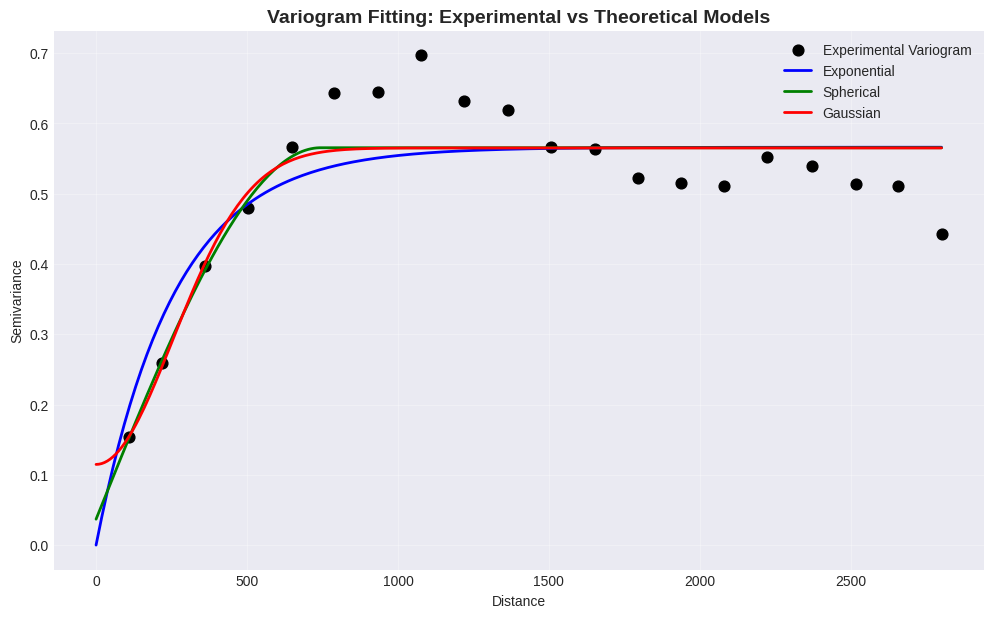

In [19]:
# ============================================================
# VISUALISASI FITTING VARIOGRAM
# ============================================================


plt.figure(figsize=(12,7))


# empirical

plt.scatter(

    distances,

    variogram,

    color="black",

    s=60,

    label="Experimental Variogram"

)



h_plot=np.linspace(

    0,

    max(distances),

    300

)



colors={

    "exponential":"blue",

    "spherical":"green",

    "gaussian":"red"

}



for model_name, params in models.items():


    if model_name=="exponential":


        gamma = variogram_model_exponential(

            h_plot,

            params["nugget"],

            params["sill"],

            params["range"]

        )



    elif model_name=="spherical":


        gamma = variogram_model_spherical(

            h_plot,

            params["nugget"],

            params["sill"],

            params["range"]

        )



    else:


        gamma = variogram_model_gaussian(

            h_plot,

            params["nugget"],

            params["sill"],

            params["range"]

        )



    plt.plot(

        h_plot,

        gamma,

        color=colors[model_name],

        linewidth=2,

        label=model_name.capitalize()

    )



plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Semivariance"
)


plt.title(
    "Variogram Fitting: Experimental vs Theoretical Models",
    fontsize=14,
    fontweight="bold"
)



plt.legend()


plt.grid(alpha=0.3)


plt.show()

In [20]:
# ============================================================
# TABEL PARAMETER MODEL
# ============================================================


variogram_table = pd.DataFrame(models).T


variogram_table

,nugget,sill,range,SSE
exponential,0.000000,0.566025,258.321681,0.085624
spherical,0.036849,0.528460,744.093400,0.066443
gaussian,0.114772,0.450234,359.206157,0.067576


Nilai nugget yang relatif kecil menunjukkan bahwa variasi pada jarak sangat dekat dan error pengukuran tidak terlalu besar.artinya data Zinc cukup konsisten,
variasi lokal masih dapat dijelaskan oleh struktur spasial.

Sill menunjukkan batas maksimum variasi spasial.artinya Ketika jarak meningkat, perbedaan nilai Zinc mencapai kondisi stabil sekitar nilai tersebut.

Range menunjukkan jarak dimana hubungan spasial masih berpengaruh. artinya Lokasi yang berjarak kurang dari sekitar 744 unit masih memiliki hubungan spasial terhadap kandungan Zinc, sedangkan lokasi yang lebih jauh cenderung tidak memiliki pengaruh spasial yang kuat.

Berdasarkan hasil fitting model variogram, ketiga model teoritis mampu mengikuti pola experimental variogram. Model spherical memberikan nilai SSE terkecil dibandingkan model exponential dan gaussian, sehingga dipilih sebagai model variogram terbaik. Kurva spherical mampu menggambarkan peningkatan semivariance pada jarak pendek hingga mencapai kondisi stabil (sill) secara lebih sesuai terhadap pola data observasi.

# 10. ORDINARY KRIGING PREDICTION

Ordinary Kriging digunakan untuk melakukan interpolasi nilai Log(Zinc) pada lokasi yang belum diamati berdasarkan:

lokasi sampel,
nilai observasi,
model variogram terbaik (Spherical).

Output yang akan diperoleh:

Peta prediksi Log(Zinc)
Kriging variance (tingkat ketidakpastian prediksi)

In [23]:
# =============================================================================
# 10. ORDINARY KRIGING PREDICTION
# =============================================================================


print("\n" + "="*80)
print("ORDINARY KRIGING PREDICTION")
print("="*80)



# Mengambil model terbaik berdasarkan SSE terkecil

best_model = (
    variogram_table["SSE"]
    .idxmin()
)



print(
    "Model variogram terbaik:",
    best_model.upper()
)


ORDINARY KRIGING PREDICTION
Model variogram terbaik: SPHERICAL


In [24]:
# Parameter model terbaik

best_params = models[best_model]


print("\nParameter Kriging:")


print(
    "Nugget :",
    round(best_params["nugget"],4)
)


print(
    "Sill :",
    round(best_params["sill"],4)
)


print(
    "Range :",
    round(best_params["range"],2)
)


Parameter Kriging:
Nugget : 0.0368
Sill : 0.5285
Range : 744.09


In [25]:
# =============================================================================
# GRID PREDIKSI
# =============================================================================


grid_resolution = 100


x_pred = np.linspace(
    x.min(),
    x.max(),
    grid_resolution
)


y_pred = np.linspace(
    y.min(),
    y.max(),
    grid_resolution
)



X_pred, Y_pred = np.meshgrid(
    x_pred,
    y_pred
)



print(
    f"Grid prediksi: {grid_resolution} x {grid_resolution}"
)

print(
    f"Jumlah titik prediksi: {grid_resolution**2:,}"
)

Grid prediksi: 100 x 100
Jumlah titik prediksi: 10,000


In [26]:
# =============================================================================
# ORDINARY KRIGING MODEL
# =============================================================================


OK = OrdinaryKriging(

    x,

    y,

    zinc_log,


    variogram_model=best_model,


    variogram_parameters={

        "sill": best_params["sill"],

        "range": best_params["range"],

        "nugget": best_params["nugget"]

    },


    verbose=False,

    enable_plotting=False

)



print("Model Ordinary Kriging berhasil dibuat")

Model Ordinary Kriging berhasil dibuat


In [27]:
# =============================================================================
# MELAKUKAN PREDIKSI
# =============================================================================


z_pred, ss_pred = OK.execute(

    "grid",

    x_pred,

    y_pred

)



print("\nPrediksi Kriging selesai")


print(
    "Shape prediksi:",
    z_pred.shape
)


print(
    "Range prediksi:"
)

print(
    z_pred.min(),
    "-",
    z_pred.max()
)


print(
    "\nRange variance:"
)


print(
    ss_pred.min(),
    "-",
    ss_pred.max()
)


Prediksi Kriging selesai
Shape prediksi: (100, 100)
Range prediksi:
4.766017157669964 - 7.478817082907979

Range variance:
0.0648412317451507 - 0.5540507113391366


Ordinary Kriging berhasil dilakukan menggunakan model variogram spherical sebagai model terbaik berdasarkan nilai SSE terkecil. Prediksi dilakukan pada grid spasial dengan resolusi 100×100 titik. Selain menghasilkan nilai prediksi Log(Zinc), metode ini juga menghasilkan kriging variance yang menunjukkan tingkat ketidakpastian estimasi pada setiap lokasi.

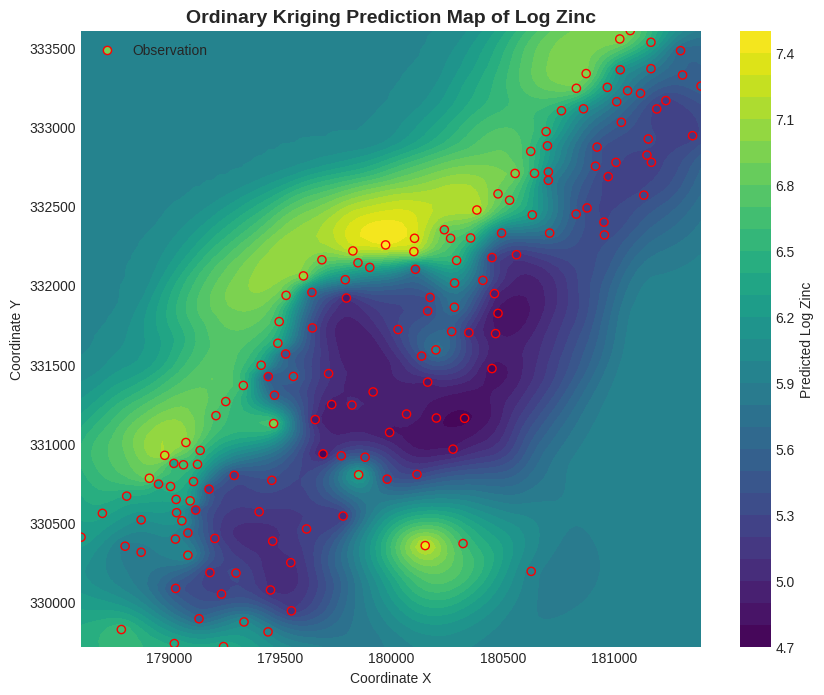

In [29]:
# =============================================================================
# PETA HASIL ORDINARY KRIGING
# =============================================================================


plt.figure(figsize=(10,8))


contour = plt.contourf(

    X_pred,

    Y_pred,

    z_pred,

    levels=30,

    cmap="viridis"

)



plt.colorbar(
    contour,
    label="Predicted Log Zinc"
)



plt.scatter(

    x,

    y,

    c=zinc_log,

    cmap="viridis",

    edgecolor="red",

    s=35,

    label="Observation"

)



plt.xlabel(
    "Coordinate X"
)


plt.ylabel(
    "Coordinate Y"
)


plt.title(
    "Ordinary Kriging Prediction Map of Log Zinc",
    fontsize=14,
    fontweight="bold"
)


plt.legend()


plt.show()

Hasil Ordinary Kriging menunjukkan pola distribusi spasial Log(Zinc) pada seluruh area penelitian. Zona dengan warna lebih terang menunjukkan lokasi dengan estimasi kandungan Zinc lebih tinggi, sedangkan warna lebih gelap menunjukkan nilai yang lebih rendah. Pola prediksi mengikuti struktur spasial yang diperoleh dari model variogram spherical.

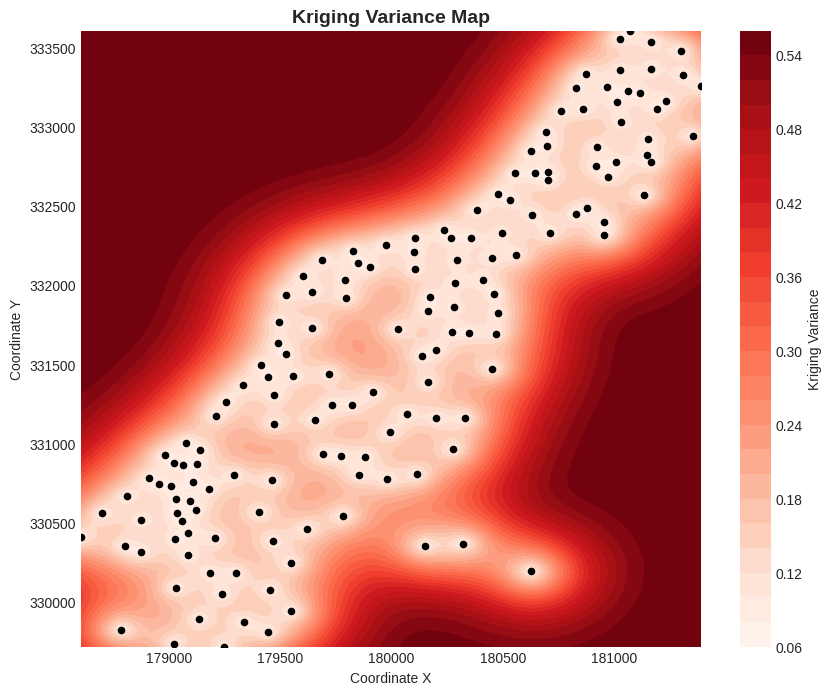

In [30]:
# =============================================================================
# KRIGING VARIANCE MAP
# =============================================================================


plt.figure(figsize=(10,8))


variance_plot = plt.contourf(

    X_pred,

    Y_pred,

    ss_pred,

    levels=30,

    cmap="Reds"

)



plt.colorbar(
    variance_plot,
    label="Kriging Variance"
)



plt.scatter(

    x,

    y,

    color="black",

    s=20

)



plt.xlabel(
    "Coordinate X"
)


plt.ylabel(
    "Coordinate Y"
)


plt.title(
    "Kriging Variance Map",
    fontsize=14,
    fontweight="bold"
)


plt.show()

Peta kriging variance menunjukkan tingkat ketidakpastian prediksi. Area dengan nilai variance tinggi menunjukkan lokasi yang memiliki ketidakpastian lebih besar akibat keterbatasan informasi dari titik pengamatan di sekitarnya.

Ordinary Kriging berhasil dilakukan menggunakan model variogram spherical sebagai model terbaik berdasarkan nilai SSE terkecil. Parameter variogram menunjukkan adanya struktur ketergantungan spasial pada kandungan Zinc dengan range sekitar 744 unit koordinat. Hasil interpolasi menunjukkan variasi spasial Log(Zinc) yang mengikuti pola distribusi lokasi pengamatan. Kriging variance menunjukkan bahwa ketidakpastian prediksi meningkat pada area dengan jumlah informasi spasial yang lebih rendah.

# 11. VALIDASI DAN EVALUASI PERFORMANCE

Validasi dilakukan untuk mengetahui seberapa baik model Ordinary Kriging dalam memprediksi nilai Zinc pada lokasi yang sudah diketahui.

Metode yang digunakan:

Leave-One-Out Cross Validation (LOOCV)

Prinsipnya:

satu titik observasi dikeluarkan,
model dibuat menggunakan titik lainnya,
nilai pada titik yang dikeluarkan diprediksi,
hasil prediksi dibandingkan dengan nilai sebenarnya.

In [31]:
# =============================================================================
# 11. VALIDASI DAN EVALUASI PERFORMANCE
# =============================================================================


print("\n" + "="*80)
print("VALIDASI DAN EVALUASI MODEL")
print("="*80)



def loo_cross_validation(
    x,
    y,
    z,
    variogram_model,
    variogram_parameters
):

    n = len(z)

    predictions = np.zeros(n)

    variances = np.zeros(n)



    for i in range(n):


        # data training

        x_train = np.delete(x,i)

        y_train = np.delete(y,i)

        z_train = np.delete(z,i)



        # titik validasi

        x_test = x[i]

        y_test = y[i]



        # model kriging

        OK_cv = OrdinaryKriging(

            x_train,

            y_train,

            z_train,

            variogram_model=variogram_model,

            variogram_parameters=variogram_parameters,

            verbose=False

        )



        pred, var = OK_cv.execute(

            "points",

            [x_test],

            [y_test]

        )


        predictions[i] = pred[0]

        variances[i] = var[0]



    return predictions, variances


TAHAP 9: VALIDASI DAN EVALUASI MODEL


In [33]:
# =============================================================================
# PERBAIKAN TIPE DATA KOORDINAT UNTUK KRIGING
# =============================================================================


x = np.array(x, dtype=float)

y = np.array(y, dtype=float)

zinc_log = np.array(zinc_log, dtype=float)



print("Tipe data koordinat:")
print(x.dtype)
print(y.dtype)
print(zinc_log.dtype)

Tipe data koordinat:
float64
float64
float64


In [34]:
# =============================================================================
# CROSS VALIDATION
# =============================================================================


cv_pred, cv_var = loo_cross_validation(

    x,

    y,

    zinc_log,

    best_model,

    {
        "sill":best_params["sill"],
        "range":best_params["range"],
        "nugget":best_params["nugget"]
    }

)


print("Cross validation selesai")

Cross validation selesai


In [35]:
# =============================================================================
# METRIK EVALUASI
# =============================================================================


rmse = np.sqrt(
    mean_squared_error(
        zinc_log,
        cv_pred
    )
)


mae = mean_absolute_error(
    zinc_log,
    cv_pred
)


r2 = r2_score(
    zinc_log,
    cv_pred
)



print("\nHasil Evaluasi Model:")

print(
    "RMSE :",
    round(rmse,4)
)


print(
    "MAE  :",
    round(mae,4)
)


print(
    "R²   :",
    round(r2,4)
)


Hasil Evaluasi Model:
RMSE : 0.391
MAE  : 0.2919
R²   : 0.7047


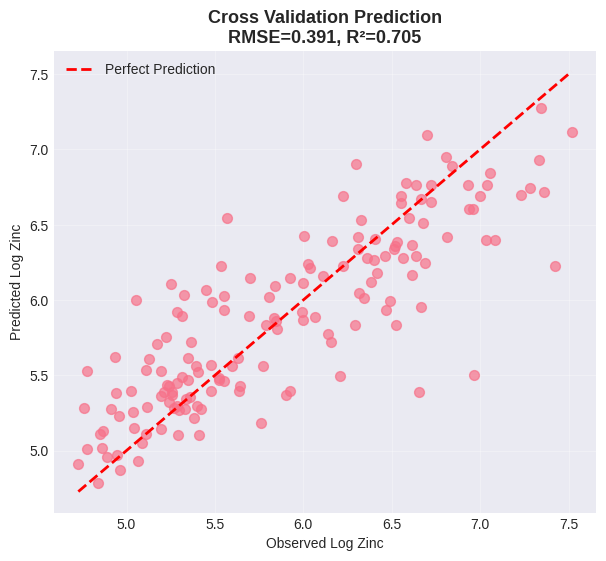

In [36]:
# =============================================================================
# OBSERVED VS PREDICTED
# =============================================================================


plt.figure(figsize=(7,6))


plt.scatter(

    zinc_log,

    cv_pred,

    s=50,

    alpha=0.7

)



# garis prediksi sempurna

min_val = min(
    zinc_log.min(),
    cv_pred.min()
)


max_val = max(
    zinc_log.max(),
    cv_pred.max()
)



plt.plot(

    [min_val,max_val],

    [min_val,max_val],

    'r--',

    linewidth=2,

    label="Perfect Prediction"

)



plt.xlabel(
    "Observed Log Zinc"
)


plt.ylabel(
    "Predicted Log Zinc"
)


plt.title(
    f"Cross Validation Prediction\nRMSE={rmse:.3f}, R²={r2:.3f}",
    fontsize=13,
    fontweight="bold"
)


plt.legend()


plt.grid(alpha=0.3)


plt.show()

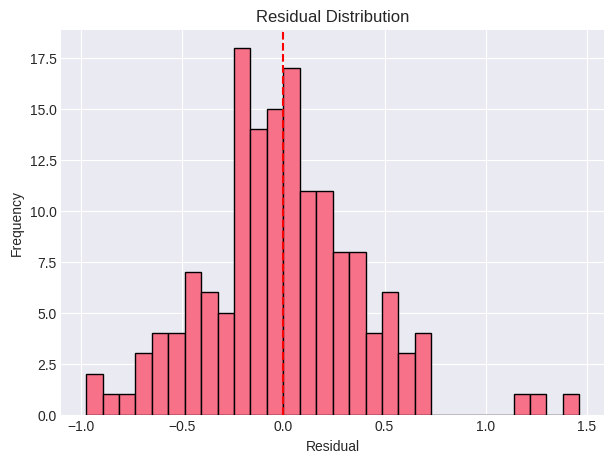

In [37]:
# =============================================================================
# RESIDUAL ANALYSIS
# =============================================================================


residual = zinc_log - cv_pred



plt.figure(figsize=(7,5))


plt.hist(

    residual,

    bins=30,

    edgecolor="black"

)



plt.axvline(

    0,

    color="red",

    linestyle="--"

)



plt.xlabel(
    "Residual"
)


plt.ylabel(
    "Frequency"
)


plt.title(
    "Residual Distribution"
)


plt.show()

Berdasarkan hasil Leave-One-Out Cross Validation, model Ordinary Kriging dengan variogram spherical menunjukkan performa prediksi yang baik. Model menghasilkan nilai RMSE sebesar 0.391 dan MAE sebesar 0.2919 pada skala Log(Zinc), dengan nilai koefisien determinasi (R²) sebesar 0.7047. Hal ini menunjukkan bahwa sekitar 70.47% variasi spasial kandungan Zinc dapat dijelaskan oleh model. Grafik hubungan antara nilai observasi dan prediksi menunjukkan pola linear positif, sedangkan distribusi residual menunjukkan kesalahan prediksi yang relatif seimbang di sekitar nilai nol.

12. ANALISIS KETIDAKPASTIAN (UNCERTAINTY ANALYSIS)

In [ ]:
Ordinary Kriging tidak hanya menghasilkan nilai prediksi, tetapi juga menghasilkan kriging variance.

Kriging variance menunjukkan tingkat ketidakpastian prediksi:

variance kecil → prediksi lebih terpercaya
variance besar → prediksi lebih tidak pasti

Biasanya ketidakpastian tinggi muncul pada:

lokasi jauh dari titik observasi,
area dengan jumlah sampel sedikit.

In [40]:
# =============================================================================
# 12. ANALISIS KETIDAKPASTIAN
# =============================================================================


print("\n" + "="*80)
print(" ANALISIS KETIDAKPASTIAN")
print("="*80)



print("Statistik Kriging Variance")


print(
    "Mean :",
    round(ss_pred.mean(),4)
)


print(
    "Std  :",
    round(ss_pred.std(),4)
)


print(
    "Min  :",
    round(ss_pred.min(),4)
)


print(
    "Max  :",
    round(ss_pred.max(),4)
)


 ANALISIS KETIDAKPASTIAN
Statistik Kriging Variance
Mean : 0.3409
Std  : 0.1804
Min  : 0.0648
Max  : 0.5541


In [47]:
# =============================================================================
# AREA UNCERTAINTY TINGGI
# =============================================================================


threshold = np.percentile(
    ss_pred,
    90
)



high_uncertainty = ss_pred >= threshold



print("\nThreshold uncertainty tinggi:")

print(
    round(threshold,4)
)


print(
    "Jumlah lokasi:",
    high_uncertainty.sum()
)


print(
    "Persentase:",
    round(
        high_uncertainty.sum()
        /
        ss_pred.size
        *
        100,
        2
    ),
    "%"
)


Threshold uncertainty tinggi:
0.5541
Jumlah lokasi: 1635
Persentase: 16.35 %


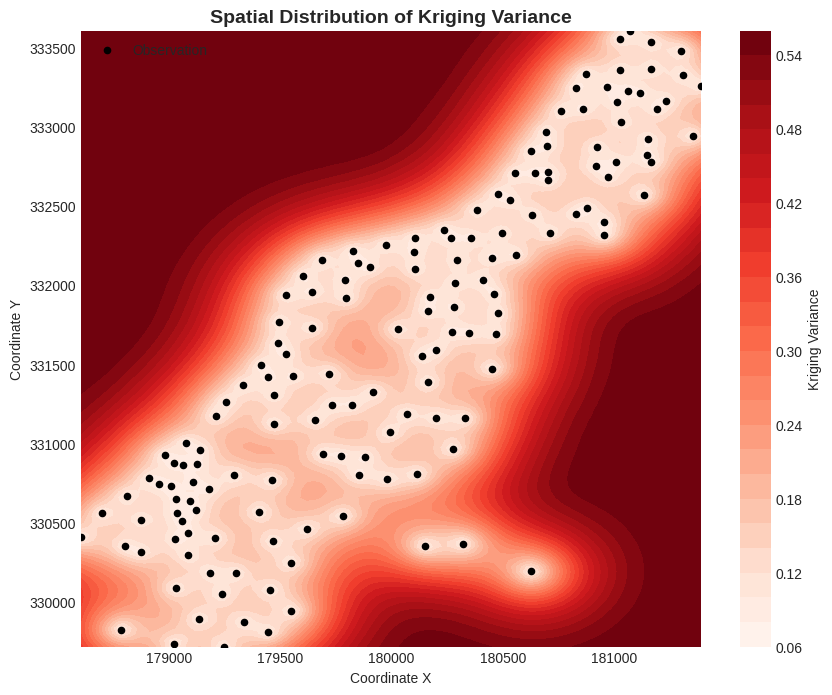

In [48]:
# =============================================================================
# PETA KETIDAKPASTIAN
# =============================================================================


plt.figure(figsize=(10,8))


var_map = plt.contourf(

    X_pred,

    Y_pred,

    ss_pred,

    levels=30,

    cmap="Reds"

)



plt.colorbar(
    var_map,
    label="Kriging Variance"
)



plt.scatter(

    x,

    y,

    color="black",

    s=20,

    label="Observation"

)



plt.xlabel(
    "Coordinate X"
)


plt.ylabel(
    "Coordinate Y"
)


plt.title(
    "Spatial Distribution of Kriging Variance",
    fontsize=14,
    fontweight="bold"
)


plt.legend()


plt.show()

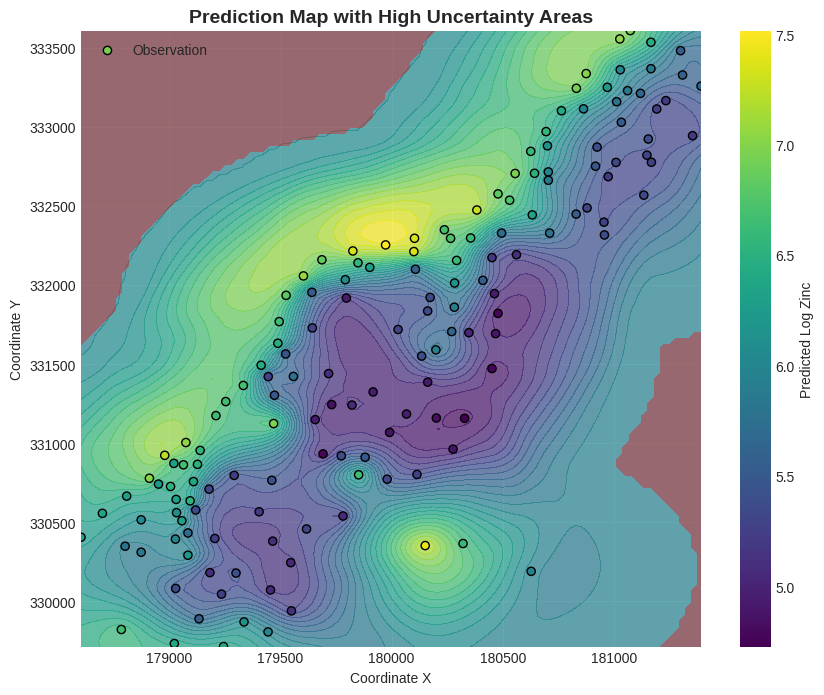

In [50]:
# =============================================================================
# PETA AREA UNCERTAINTY TINGGI
# =============================================================================


plt.figure(figsize=(10,8))


# peta prediksi dasar

plt.contourf(
    X_pred,
    Y_pred,
    z_pred,
    levels=30,
    cmap="viridis",
    alpha=0.7
)



# hanya tampilkan area uncertainty tinggi

plt.contourf(
    X_pred,
    Y_pred,
    high_uncertainty.astype(int),
    levels=[0.5,1],
    colors="red",
    alpha=0.35
)



plt.scatter(
    x,
    y,
    c=zinc_log,
    cmap="viridis",
    edgecolor="black",
    s=35,
    label="Observation"
)



plt.colorbar(
    label="Predicted Log Zinc"
)



plt.title(
    "Prediction Map with High Uncertainty Areas",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel("Coordinate X")

plt.ylabel("Coordinate Y")


plt.legend()


plt.show()

# 13. BACK TRANSFORMATION LOG(ZINC)

Karena sebelumnya kita menggunakan:

$$ Log(Zinc) $$

maka hasil prediksi perlu dikembalikan ke skala asli agar lebih mudah diinterpretasikan.

In [51]:
# =============================================================================
# 13. BACK TRANSFORMATION
# =============================================================================


print("\n" + "="*80)
print("TAHAP 11: BACK TRANSFORMATION ZINC")
print("="*80)



# Mengembalikan Log Zinc ke Zinc asli

zinc_pred = np.exp(z_pred)



print("Range prediksi Zinc asli:")


print(
    "Minimum :",
    round(zinc_pred.min(),2)
)


print(
    "Maximum :",
    round(zinc_pred.max(),2)
)


print(
    "Mean :",
    round(zinc_pred.mean(),2)
)


TAHAP 11: BACK TRANSFORMATION ZINC
Range prediksi Zinc asli:
Minimum : 117.45
Maximum : 1770.15
Mean : 455.17


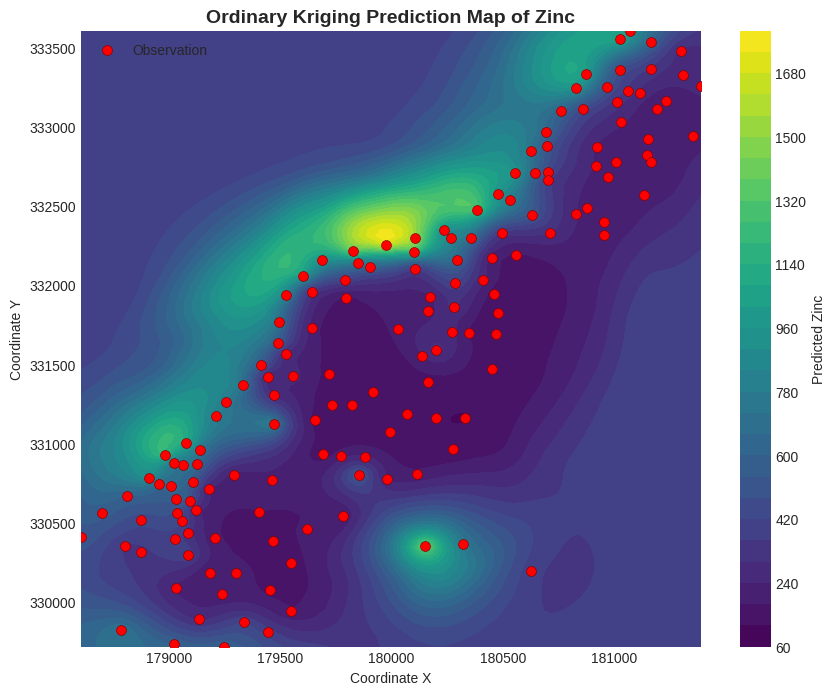

In [57]:
# =============================================================================
# PETA PREDIKSI ZINC ASLI
# =============================================================================


plt.figure(figsize=(10,8))


zinc_map = plt.contourf(

    X_pred,

    Y_pred,

    zinc_pred,

    levels=30,

    cmap="viridis"

)



plt.colorbar(
    zinc_map,
    label="Predicted Zinc"
)



plt.scatter(

    x,

    y,

    color="#FF0000",     # pure bright red

    s=50,

    alpha=1,

    edgecolors="darkred",

    linewidths=0.5,

    label="Observation"

)




plt.xlabel(
    "Coordinate X"
)


plt.ylabel(
    "Coordinate Y"
)


plt.title(
    "Ordinary Kriging Prediction Map of Zinc",
    fontsize=14,
    fontweight="bold"
)


plt.legend()


plt.show()

# 14. EXPORT HASIL KRIGING

In [58]:
# =============================================================================
# EXPORT HASIL
# =============================================================================


results_kriging = pd.DataFrame({

    "X": X_pred.ravel(),

    "Y": Y_pred.ravel(),

    "Predicted_Log_Zinc": z_pred.ravel(),

    "Predicted_Zinc": zinc_pred.ravel(),

    "Kriging_Variance": ss_pred.ravel()

})



results_kriging.to_csv(
    "hasil_ordinary_kriging_zinc.csv",
    index=False
)



print(
    "File berhasil disimpan:"
)

print(
    "hasil_ordinary_kriging_zinc.csv"
)

File berhasil disimpan:
hasil_ordinary_kriging_zinc.csv


# 15. SUMMARY DAN KESIMPULAN AKHIR

In [59]:
# =============================================================================
# SUMMARY HASIL ANALISIS
# =============================================================================


print("\n" + "="*80)
print("SUMMARY DAN KESIMPULAN")
print("="*80)



print("\n1. DATA")

print(
    "Jumlah titik observasi:",
    len(zinc)
)



print("\n2. TRANSFORMASI")

print(
    "Analisis menggunakan transformasi Log(Zinc)"
)



print("\n3. MODEL VARIOGRAM TERBAIK")


print(
    "Model:",
    best_model.upper()
)


print(
    "Nugget:",
    round(best_params["nugget"],4)
)


print(
    "Sill:",
    round(best_params["sill"],4)
)


print(
    "Range:",
    round(best_params["range"],2)
)



print("\n4. VALIDASI MODEL")


print(
    "RMSE:",
    round(rmse,4)
)


print(
    "MAE:",
    round(mae,4)
)


print(
    "R²:",
    round(r2,4)
)



print("\n5. KETIDAKPASTIAN")


print(
    "Mean Kriging Variance:",
    round(ss_pred.mean(),4)
)


print(
    "Maximum Variance:",
    round(ss_pred.max(),4)
)



print("\nKESIMPULAN:")

print(
"""
Ordinary Kriging berhasil digunakan untuk memodelkan
distribusi spasial kandungan Zinc.

Model variogram terbaik adalah Spherical berdasarkan
nilai SSE terkecil.

Hasil validasi menunjukkan model memiliki kemampuan
prediksi yang baik dengan R² sekitar 70%.

Ketidakpastian prediksi meningkat pada area yang jauh
dari titik observasi.
"""
)


SUMMARY DAN KESIMPULAN

1. DATA
Jumlah titik observasi: 155

2. TRANSFORMASI
Analisis menggunakan transformasi Log(Zinc)

3. MODEL VARIOGRAM TERBAIK
Model: SPHERICAL
Nugget: 0.0368
Sill: 0.5285
Range: 744.09

4. VALIDASI MODEL
RMSE: 0.391
MAE: 0.2919
R²: 0.7047

5. KETIDAKPASTIAN
Mean Kriging Variance: 0.3409
Maximum Variance: 0.5541

KESIMPULAN:

Ordinary Kriging berhasil digunakan untuk memodelkan
distribusi spasial kandungan Zinc.

Model variogram terbaik adalah Spherical berdasarkan
nilai SSE terkecil.

Hasil validasi menunjukkan model memiliki kemampuan
prediksi yang baik dengan R² sekitar 70%.

Ketidakpastian prediksi meningkat pada area yang jauh
dari titik observasi.

